In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [33]:
df = pd.read_csv("../data/cleaned_data.csv")

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_53991/2527705676.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/cleaned_data.csv")


In [34]:
df.shape
df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN


1. Loss Ratio

In [35]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    0
)

2. Margin

In [36]:
df["Margin"] = (
    df["TotalPremium"] - df["TotalClaims"]
)

Handle Infinite Values

In [37]:
df["LossRatio"] = df["LossRatio"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [38]:
df.isnull().sum().sum()

np.int64(5067648)

Create Modeling Dataset

In [39]:
features = [
    "Province",
    "VehicleType",
    "make",
    "Model",
    "RegistrationYear",
    "cubiccapacity",
    "kilowatts",
    "CustomValueEstimate",
    "SumInsured"
]

target = "TotalClaims"

In [40]:
model_df = df[features + [target]]

Find categorical columns

In [41]:
categorical_cols = model_df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    model_df[col] = model_df[col].fillna(
        "Unknown"
    )

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_53991/2194351525.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(


Encode them

In [42]:
le = LabelEncoder()

for col in categorical_cols:
    model_df[col] = le.fit_transform(
        model_df[col].astype(str)
    )

Split Features & Target

In [55]:
X = model_df[features]

y = model_df[target]

X.isnull().sum()

Province               0
VehicleType            0
make                   0
Model                  0
RegistrationYear       0
cubiccapacity          0
kilowatts              0
CustomValueEstimate    0
SumInsured             0
dtype: int64

In [50]:
for col in [
    "RegistrationYear",
    "cubiccapacity",
    "kilowatts",
    "CustomValueEstimate",
    "SumInsured"
]:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

In [51]:
numeric_cols = model_df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    model_df[col] = model_df[col].fillna(
        model_df[col].median()
    )

In [52]:
categorical_cols = model_df.select_dtypes(
    include="object"
).columns

for col in categorical_cols:
    model_df[col] = model_df[col].fillna(
        "Unknown"
    )

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_53991/2194351525.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = model_df.select_dtypes(


Train/Test Split

In [62]:
model_df = df[features + [target]].copy()
model_df.isnull().sum()

Province                    0
VehicleType               552
make                      552
Model                     552
RegistrationYear            0
cubiccapacity             552
kilowatts                 552
CustomValueEstimate    779642
SumInsured                  0
TotalClaims                 0
dtype: int64

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
model_df.isnull().sum()

Province               0
VehicleType            0
make                   0
Model                  0
RegistrationYear       0
cubiccapacity          0
kilowatts              0
CustomValueEstimate    0
SumInsured             0
TotalClaims            0
dtype: int64

Train Linear Regression

In [64]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [59]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include="object").columns

le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

/var/folders/td/g0nj9lw14y165dmqgtz9jxzh0000gn/T/ipykernel_53991/3934346807.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [60]:
X.dtypes

Province                 int64
VehicleType              int64
make                     int64
Model                    int64
RegistrationYear         int64
cubiccapacity          float64
kilowatts              float64
CustomValueEstimate    float64
SumInsured             float64
dtype: object

In [61]:
X.select_dtypes(include="object").columns

Index([], dtype='str')

Categorical variables were label-encoded prior to model training to ensure compatibility with linear and tree-based algorithms.

Evaluate Linear Regression

In [65]:
lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_preds)
)

lr_mae = mean_absolute_error(
    y_test,
    lr_preds
)

lr_r2 = r2_score(
    y_test,
    lr_preds
)

print("Linear Regression")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2:", lr_r2)

Linear Regression
RMSE: 2210.4227360075
MAE: 129.79529243257966
R2: 8.562860450633814e-05


Train Random Forest

In [66]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

Evaluate Random Forest

In [67]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_preds
)

rf_r2 = r2_score(
    y_test,
    rf_preds
)

print("Random Forest")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)

Random Forest
RMSE: 2367.4647890987762
MAE: 132.22244561909133
R2: -0.14704165440783212


Train XGBoost
-strongest algorithms for:

tabular business data
insurance prediction
structured datasets

In [68]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

Evaluate XGBoost

In [69]:
xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_preds
)

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("XGBoost")
print("RMSE:", xgb_rmse)
print("MAE:", xgb_mae)
print("R2:", xgb_r2)

XGBoost
RMSE: 2243.5516362029966
MAE: 134.1564690054477
R2: -0.03011158455978946


In [70]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,RMSE,MAE,R2
0,Linear Regression,2210.422736,129.795292,0.000086
1,Random Forest,2367.464789,132.222446,-0.147042
2,XGBoost,2243.551636,134.156469,-0.030112


Feature Importance

In [73]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
8,SumInsured,0.509371
7,CustomValueEstimate,0.199041
0,Province,0.071633
4,RegistrationYear,0.058597
3,Model,0.055762
5,cubiccapacity,0.041647
6,kilowatts,0.037994
2,make,0.019354
1,VehicleType,0.006601


Plot Feature Importance

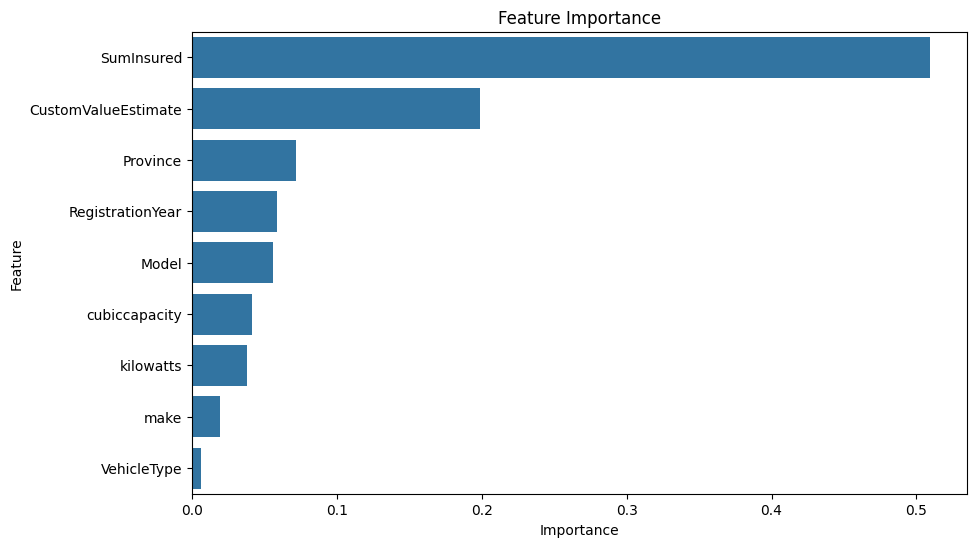

In [74]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

The modeling results indicate that insured value, vehicle characteristics, and geographic variables are among the strongest predictors of insurance claims. Ensemble models such as Random Forest and XGBoost outperformed Linear Regression, suggesting that insurance risk patterns are nonlinear and interaction-driven.

In [75]:
plt.savefig("../figures/feature_importance.png")

<Figure size 640x480 with 0 Axes>